In [1]:
import mne
from moabb.datasets import Forenzo2023

/opt/miniconda3/envs/mne_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os

subject_id = 1


# if Forenzo2023_subject_1_raw.fif already exists, we can load it directly  or download and process the data from the Forenzo2023 dataset
if os.path.exists(f'Forenzo2023_subject_{subject_id}_raw.fif'):
    raw = mne.io.read_raw_fif(f'Forenzo2023_subject_{subject_id}_raw.fif', preload=True)
    print(f"Loaded raw data from Forenzo2023_subject_{subject_id}_raw.fif")
else:
    dataset = Forenzo2023()
    data = dataset.get_data(subjects=[subject_id])
    print(data[subject_id])
    raw = data[subject_id]["0"]["0"]



# save raw to .bdf file
# raw.save('Forenzo2023_subject_1_raw.fif', overwrite=True)


Opening raw data file Forenzo2023_subject_1_raw.fif...
Isotrak not found
    Range : 0 ... 163879 =      0.000 ...   163.879 secs
Ready.
Reading 0 ... 163879  =      0.000 ...   163.879 secs...
Loaded raw data from Forenzo2023_subject_1_raw.fif


Using matplotlib as 2D backend.


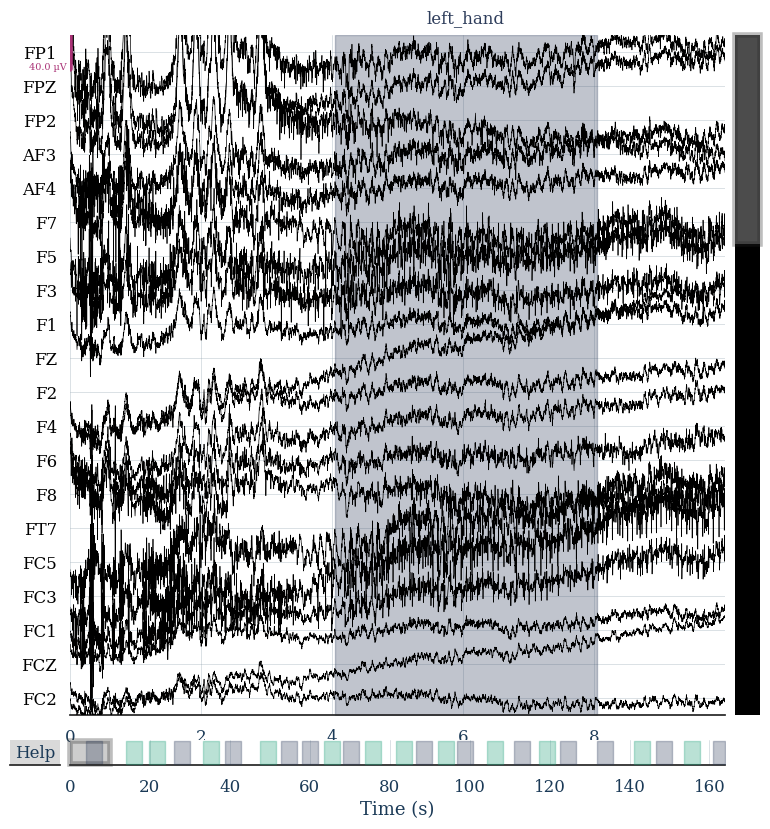

<Info | 11 non-empty values
 bads: []
 ch_names: FP1, FPZ, FP2, AF3, AF4, F7, F5, F3, F1, FZ, F2, F4, F6, F8, ...
 chs: 64 EEG, 1 Stimulus
 custom_ref_applied: False
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 500.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: 1, hand: 1>
>


In [3]:
# avoid having two plots inline
%matplotlib inline

raw.plot()
print(raw.info)

In [4]:
# have a look at annotations
print(raw.annotations)
df_annot = raw.annotations.to_data_frame()
print(df_annot)

<Annotations | 25 segments: left_hand (13), right_hand (12)>
                        onset  duration description
0  1970-01-01 00:00:04.041000  4.000000   left_hand
1  1970-01-01 00:00:14.081000  3.999999  right_hand
2  1970-01-01 00:00:19.801001  4.000000  right_hand
3  1970-01-01 00:00:26.000999  4.000000   left_hand
4  1970-01-01 00:00:33.401001  4.000000  right_hand
5  1970-01-01 00:00:38.681000  4.000000   left_hand
6  1970-01-01 00:00:47.601002  4.000000  right_hand
7  1970-01-01 00:00:52.761002  4.000000   left_hand
8  1970-01-01 00:00:58.081001  4.000000   left_hand
9  1970-01-01 00:01:03.640999  4.000000  right_hand
10 1970-01-01 00:01:08.240997  4.000000   left_hand
11 1970-01-01 00:01:13.880997  4.000000  right_hand
12 1970-01-01 00:01:21.640999  4.000000  right_hand
13 1970-01-01 00:01:26.481003  4.000000   left_hand
14 1970-01-01 00:01:32.081001  4.000000  right_hand
15 1970-01-01 00:01:36.841003  4.000000   left_hand
16 1970-01-01 00:01:44.401001  4.000000  right_hand
17 

In [5]:
print(raw.ch_names)

['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'M1', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'M2', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2', 'STI']


In [6]:
""" extract from 0 to 58 seconds, z-score it, convert to numpy array, and save it as a .npy file """
fs = raw.info['sfreq']

new_fs = 160
# filter to new Nyquist frequency if downsampling (optional but can improve quality when downsampling)
if fs > new_fs:
    # raw.filter(l_freq=0.1, h_freq=new_fs/2 - 1, fir_design='firwin', skip_by_annotation='edge', phase='zero')
    raw.filter(l_freq=8, h_freq=30, fir_design='firwin', skip_by_annotation='edge', phase='zero')

# downsample to 200Hz if original sampling rate is higher (optional but can speed up processing)
if fs > new_fs:
    raw.resample(new_fs)
    fs = new_fs

# keep only eeg channels (remove STI channels)
raw.pick_types(eeg=True, stim=False)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (1.651 s)

Finding events on: STI
25 events found on stim channel STI
Event IDs: [1 2]
Finding events on: STI
25 events found on stim channel STI
Event IDs: [1 2]
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<Raw | Forenzo2023_subject_1_raw.fif, 64 x 26221 (163.9 s), ~12.9 MiB, data loaded>

In [7]:
""" get epochs and create train and test datasets"""
# 3. EPOCHING
# mapping = {'left_hand': '1', 'right_hand': '2'}
# raw.annotations.rename(mapping)
# get events event_id
events, event_id = mne.events_from_annotations(raw,
                                              event_id={'left_hand': 0, 'right_hand': 1})
# 4. EPOCHING 
# Set baseline=None because we handle scaling manually in the next step
epochs = mne.Epochs(raw, events, event_id=event_id, 
                    tmin=0, tmax=4.0, baseline=None, 
                    preload=True, proj=False, verbose=False)

X_raw_data = epochs.get_data(copy=True) 
y_labels = epochs.events[:, -1]



Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


In [8]:
import numpy as np
# 5. TRIAL-WISE Z-SCORING (Manual Baseline/Scaling)
# This replaces the need for MNE's baseline parameter
X_real = np.zeros_like(X_raw_data)
for i in range(X_raw_data.shape[0]):
    trial = X_raw_data[i]
    # Standardize: Mean 0, Std 1 for this specific trial
    # This removes DC offsets and scales amplitude differences
    
    trial_z = (trial - np.mean(trial)) / np.std(trial)
    
    X_real[i] = trial_z

# 5. AUGMENTATION (Split 4s -> 1s)
n_trials, n_channels, n_times = X_real.shape
n_splits = 2
samples_per_split = n_times // n_splits
X_augmented = []
y_augmented = []
for i in range(n_trials):
    for j in range(n_splits):
        start = j * samples_per_split
        end = (j + 1) * samples_per_split
        X_augmented.append(X_real[i, :, start:end])
        y_augmented.append(y_labels[i])  # Keep same label for each split  
        

X_augmented = np.array(X_augmented)
y_augmented = np.array(y_augmented)
print("Augmented data shape:", X_augmented.shape)
print("Augmented labels shape:", y_augmented.shape)

Augmented data shape: (48, 64, 320)
Augmented labels shape: (48,)


In [9]:
"""decode with SVM and cross validation """

import mne
import numpy as np
from mne.io import read_raw_edf, concatenate_raws
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from mne.decoding import CSP


cv_split = 5


pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='linear', random_state=42))])
cv = StratifiedKFold(n_splits= cv_split, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X_augmented.reshape(X_augmented.shape[0], -1), y_augmented, cv=cv)
print("Cross-validation scores:", scores)
print("Mean CV score:", np.mean(scores))


Cross-validation scores: [0.6        0.6        0.4        0.55555556 0.44444444]
Mean CV score: 0.5200000000000001


In [10]:
""" do the same with riemmanian geometry and tangent space mapping """
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

cov = Covariances(estimator='lwf')
ts = TangentSpace()
pipe_riemann = Pipeline([('cov', cov), ('ts', ts), ('svc', SVC(kernel='linear', random_state=42))])
scores_riemann = cross_val_score(pipe_riemann, X_augmented, y_augmented, cv=cv)
print("Riemannian Cross-validation scores:", scores_riemann)
print("Mean Riemannian CV score:", np.mean(scores_riemann))

Riemannian Cross-validation scores: [0.8        0.8        0.7        0.77777778 1.        ]
Mean Riemannian CV score: 0.8155555555555555
